**Exercice 1**

Ecrire un programme python qui récupère et affiche à la console le contenu du fichier robot.txt de
fr.wikipedia.org

Pistes à explorer : requests.get(url), text

In [1]:
from bs4 import BeautifulSoup
import requests

url = "https://fr.wikipedia.org/robots.txt"

headers = {
    "User-Agent": "MonRobotExercice/1.0 (contact: matthieucatteyfaye@gmail.com)"
}

page = requests.get(url=url, headers=headers)

print(page.text)

# robots.txt for http://www.wikipedia.org/ and friends
#
# Please note: There are a lot of pages on this site, and there are
# some misbehaved spiders out there that go _way_ too fast. If you're
# irresponsible, your access to the site may be blocked.
#

# Observed spamming large amounts of https://en.wikipedia.org/?curid=NNNNNN
# and ignoring 429 ratelimit responses, claims to respect robots:
# http://mj12bot.com/
User-agent: MJ12bot
Disallow: /

# advertising-related bots:
User-agent: Mediapartners-Google*
Disallow: /

# Wikipedia work bots:
User-agent: IsraBot
Disallow:

User-agent: Orthogaffe
Disallow:

# Crawlers that are kind enough to obey, but which we'd rather not have
# unless they're feeding search engines.
User-agent: UbiCrawler
Disallow: /

User-agent: DOC
Disallow: /

User-agent: Zao
Disallow: /

# Some bots are known to be trouble, particularly those designed to copy
# entire sites. Please obey robots.txt.
User-agent: sitecheck.internetseer.com
Disallow: /

User-agent: Z

**Exercice 2**

Ecrire un programme python qui récupère le nombre de datasets disponibles dans
http://www.data.gov/

Pistes à explorer: requests.get(url), BeautifulSoup, html.parser, findall(balise), get_text()

In [ ]:
from bs4 import BeautifulSoup
import requests

url = "http://www.data.gov/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

try:
    response = requests.get(url, headers=headers, timeout=10)
    html_pur = response.text
    soup = BeautifulSoup(html_pur, "html.parser")

    print("--- RECHERCHE ET EXTRACTION DU COMPTEUR ---")
    
    balise_compteur = soup.find("span", class_="text-color-red")
    
    if balise_compteur:
        nombre_datasets = balise_compteur.get_text().strip()
        
        print(f"Le nombre a été extrait avec succès !")
        print(f"Nombre de datasets : {nombre_datasets}")
        
    else:
        print("La balise spécifique n'a pas pu être trouvée.")

except requests.exceptions.RequestException as e:
    print(f"Erreur lors de la connexion : {e}")

--- RECHERCHE ET EXTRACTION DU COMPTEUR ---
Le nombre a été extrait avec succès !
Nombre de datasets : 360,111


**Exercice 3**

Ecrire un programme python qui extrait le tag h1 à partir de https://www.linkedin.com/

Pistes à explorer : requests.get(url), BeautifulSoup, html.parser, content.h1

In [3]:
from bs4 import BeautifulSoup
import requests

url = "https://www.linkedin.com/"

page = requests.get(url=url)

soup = BeautifulSoup(page.text, 'html.parser')

h1_direct = soup.h1

h1_find = soup.find('h1')

print("Balise HTML complète :", h1_direct)
if h1_direct:
    print("Texte à l'intérieur :", h1_direct.get_text().strip())

Balise HTML complète : <h1 class="font-sans babybear:pb-3 font-regular leading-regular text-display-lg text-color-text babybear:text-display-md babybear:text-center" data-test-id="hero__headline">
          Welcome to your professional community
        </h1>
Texte à l'intérieur : Welcome to your professional community


**Exercice 4**

Ecrire un programme python qui extrait et affiche tous les tags de type headers à partir de
en.wikipedia.org/wiki/Main_Page

Pistes à explorer : requests.get(url), BeautifulSoup, html.parser, find_all(list_of_tags)


In [4]:
from bs4 import BeautifulSoup
import requests

url = "https://en.wikipedia.org/wiki/Main_Page"

headers = {
    "User-Agent": "MonRobotExercice/1.0 (contact: matthieucatteyfaye@gmail.com)"
}

page = requests.get(url=url, headers=headers)

soup = BeautifulSoup(page.text, 'html.parser')

soup.find_all('header')

[<header class="vector-header mw-header no-font-mode-scale">
 <div class="vector-header-start">
 <nav aria-label="Site" class="vector-main-menu-landmark">
 <div class="vector-dropdown vector-main-menu-dropdown vector-button-flush-left vector-button-flush-right" id="vector-main-menu-dropdown" title="Main menu">
 <input aria-haspopup="true" aria-label="Main menu" class="vector-dropdown-checkbox" data-event-name="ui.dropdown-vector-main-menu-dropdown" id="vector-main-menu-dropdown-checkbox" role="button" type="checkbox"/>
 <label aria-hidden="true" class="vector-dropdown-label cdx-button cdx-button--fake-button cdx-button--fake-button--enabled cdx-button--weight-quiet cdx-button--icon-only" for="vector-main-menu-dropdown-checkbox" id="vector-main-menu-dropdown-label"><span class="vector-icon mw-ui-icon-menu mw-ui-icon-wikimedia-menu"></span>
 <span class="vector-dropdown-label-text">Main menu</span>
 </label>
 <div class="vector-dropdown-content">
 <div class="vector-unpinned-container" i

**Exercice 5**

Ecrire un programme python qui extrait et affiche tous les liens vers les images de la page wikipedia
de la reine Elisabeth II.

Pistes à explorer : requests.get(url), BeautifulSoup, html.parser, find_all(tag)

In [5]:
from bs4 import BeautifulSoup
import requests

url = "https://en.wikipedia.org/wiki/Elizabeth_II"

headers = {
    "User-Agent": "MonRobotExercice/1.0 (contact: matthieucatteyfaye@gmail.com)"
}

page = requests.get(url=url, headers=headers)

soup = BeautifulSoup(page.text, 'html.parser')

soup.find_all('img')

[<img alt="" aria-hidden="true" class="mw-logo-icon" height="50" src="/static/images/icons/enwiki-25.svg" width="50"/>,
 <img alt="Wikipedia" class="mw-logo-wordmark" src="/static/images/mobile/copyright/wikipedia-wordmark-en-25.svg" style="width: 8.75em; height: 1.375em;"/>,
 <img alt="The Free Encyclopedia" class="mw-logo-tagline" height="11" src="/static/images/mobile/copyright/wikipedia-tagline-en-25.svg" style="width: 8.75em; height: 0.6875em;" width="140"/>,
 <img alt="Featured article" class="mw-file-element" data-file-height="443" data-file-width="466" decoding="async" height="19" src="//upload.wikimedia.org/wikipedia/en/thumb/e/e7/Cscr-featured.svg/20px-Cscr-featured.svg.png" srcset="//upload.wikimedia.org/wikipedia/en/thumb/e/e7/Cscr-featured.svg/40px-Cscr-featured.svg.png 2x" width="20"/>,
 <img alt="Page semi-protected" class="mw-file-element" data-file-height="512" data-file-width="512" decoding="async" height="20" src="//upload.wikimedia.org/wikipedia/en/thumb/1/1b/Semi-p

**Exercice 6**

Ecrire un programme python qui affiche le nombre de followers d’un compte twitter.

Pistes à explorer : requests.get(url), BeautifulSoup, lxml, find(tag,class), io

In [ ]:
from bs4 import BeautifulSoup
import requests
import io

url = "https://x.com/Frederic_Molas"

headers = {
    "User-Agent": "Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)"
}

try:
    response = requests.get(url, headers=headers, timeout=10)

    html_stream = io.StringIO(response.text)

    soup = BeautifulSoup(html_stream, 'lxml')

    meta_desc = soup.find("meta", attrs={"name": "description"})
    
    if meta_desc:
        texte_complet = meta_desc.get("content", "")
        print("--- Extraction réussie ---")
        print("Texte trouvé :", texte_complet)

        if "Followers" in texte_complet:
            nb_followers = texte_complet.split("Followers")[0].split()[-1]
            print(f"Nombre de followers : {nb_followers}")
        elif "abonnés" in texte_complet:
            nb_followers = texte_complet.split("abonnés")[0].split()[-1]
            print(f"Nombre d'abonnés : {nb_followers}")
            
    else:
        print("Impossible de trouver les données du profil dans le HTML reçu.")

except Exception as e:
    print(f"Erreur d'exécution : {e}")

Impossible de trouver les données du profil dans le HTML reçu.


**Exercice 7**

Ecrire un programme python qui affiche la météo (température, vitesse du vent, description, etc.)
d’une ville donnée.

Pistes à explorer : requests.get(url), json, openweathermap API

**Brief projet**

Analyse de l’évolution des meilleures performances en triple saut de 1891 à 2019.

**Etape 1**

Analyse le contenu du site http://trackfield.brinkster.net/Main.asp?P=F

**Etape 2**

Récupérer l’url des 25 meilleures performances en triple saut de l’année 2019

**Etape 3**

Récupérer les informations que vous jugez utiles sous forme de DataFrame

**Etape 4**

Ecrire un programme qui permet d’extraire les 25 meilleures performances de l’année 1891 à 2019 en triple saut homme et femme dans un fichier Excel.

**Etape 5**

Effectuer une étude statistique sur ces données

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "http://trackfield.brinkster.net/events.asp"
annees = range(1891, 2020)
genres = {'M': 'MF4', 'W': 'WF4'}

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

all_data = []

print("Début du scraping...", flush=True)

for annee in annees:
    print(f"-> Traitement de l'année {annee}...", end=" ", flush=True)
    
    for genre, event_code in genres.items():
        params = {
            'EventCode': event_code,
            'Year': annee,
            'Gender': genre,
            'P': 'F'
        }

        max_tentatives = 3
        for tentative in range(max_tentatives):
            try:
                response = requests.get(base_url, params=params, headers=headers, timeout=10)

                if response.status_code == 200:
                    soup = BeautifulSoup(response.text, 'html.parser')
                    table = soup.find('table', {'class': 'text'}) or soup.find('table', {'cellpadding': '2'})

                    if table:
                        rows = table.find_all('tr')[1:]
                        for row in rows[:25]:
                            cols = [td.get_text(strip=True) for td in row.find_all('td')]
                            if len(cols) >= 4:
                                all_data.append({
                                    'Année': annee,
                                    'Genre': 'Homme' if genre == 'M' else 'Femme',
                                    'Rang': cols[0],
                                    'Performance (m)': cols[1],
                                    'Athlète': cols[2],
                                    'Pays': cols[3],
                                    'Date / Lieu': cols[4] if len(cols) > 4 else None
                                })
                    break
                else:
                    time.sleep(2)

            except requests.exceptions.RequestException as e:
                if tentative < max_tentatives - 1:
                    time.sleep(4)
                else:
                    print(f"\n[Erreur] Bloqué sur {annee} ({genre}) après {max_tentatives} essais.", flush=True)

        time.sleep(1)
        
    print("Ok", flush=True)
    time.sleep(1.5)

if all_data:
    df = pd.DataFrame(all_data)
    df.to_excel("triple_saut_1891_2019.xlsx", index=False)
    print(f"\nExtraction terminée avec succès ! {len(df)} lignes enregistrées.")
else:
    print("\nAttention : Aucune donnée n'a pu être récupérée.")

Début du scraping...
-> Traitement de l'année 1891... Ok
-> Traitement de l'année 1892... Ok
-> Traitement de l'année 1893... Ok
-> Traitement de l'année 1894... Ok
-> Traitement de l'année 1895... Ok
-> Traitement de l'année 1896... Ok
-> Traitement de l'année 1897... Ok
-> Traitement de l'année 1898... Ok
-> Traitement de l'année 1899... Ok
-> Traitement de l'année 1900... Ok
-> Traitement de l'année 1901... Ok
-> Traitement de l'année 1902... Ok
-> Traitement de l'année 1903... Ok
-> Traitement de l'année 1904... Ok
-> Traitement de l'année 1905... Ok
-> Traitement de l'année 1906... Ok
-> Traitement de l'année 1907... Ok
-> Traitement de l'année 1908... Ok
-> Traitement de l'année 1909... Ok
-> Traitement de l'année 1910... Ok
-> Traitement de l'année 1911... Ok
-> Traitement de l'année 1912... Ok
-> Traitement de l'année 1913... Ok
-> Traitement de l'année 1914... Ok
-> Traitement de l'année 1915... Ok
-> Traitement de l'année 1916... Ok
-> Traitement de l'année 1917... Ok
-> Trai

Nombre de lignes valides pour l'analyse : 0
--------------------------------------------------


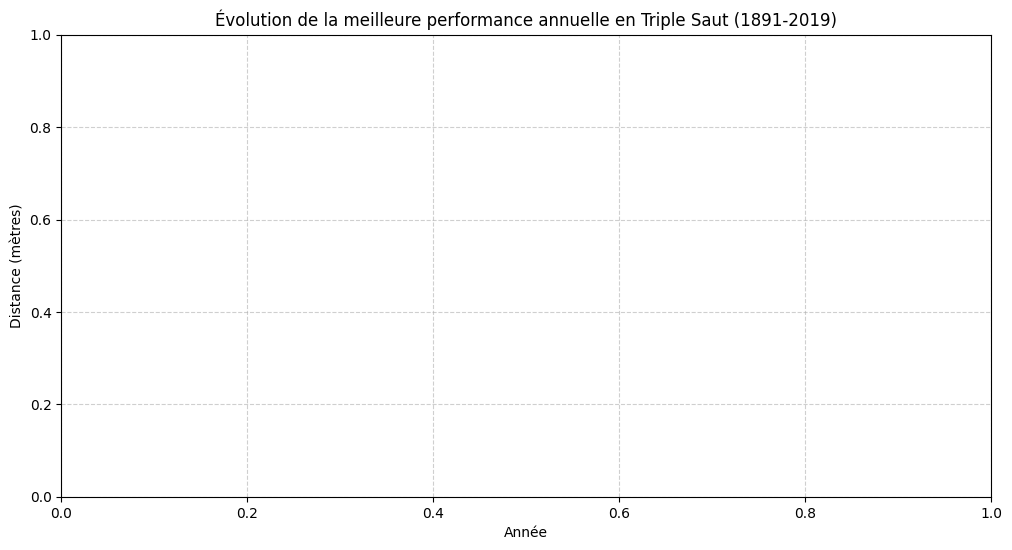

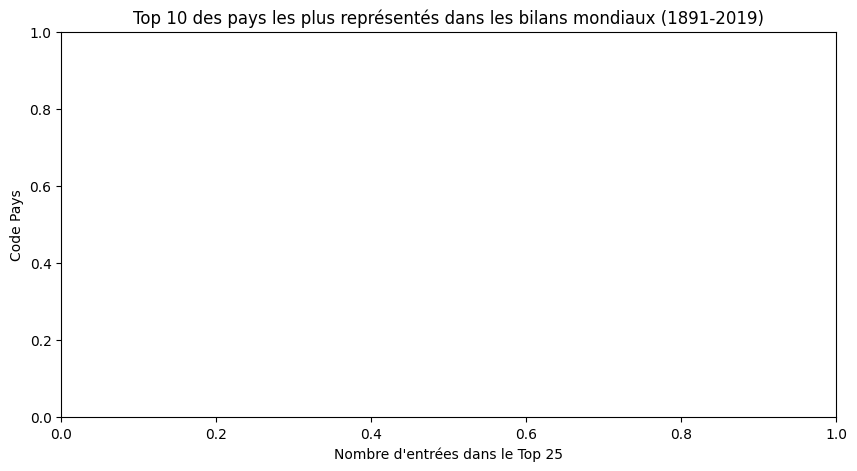

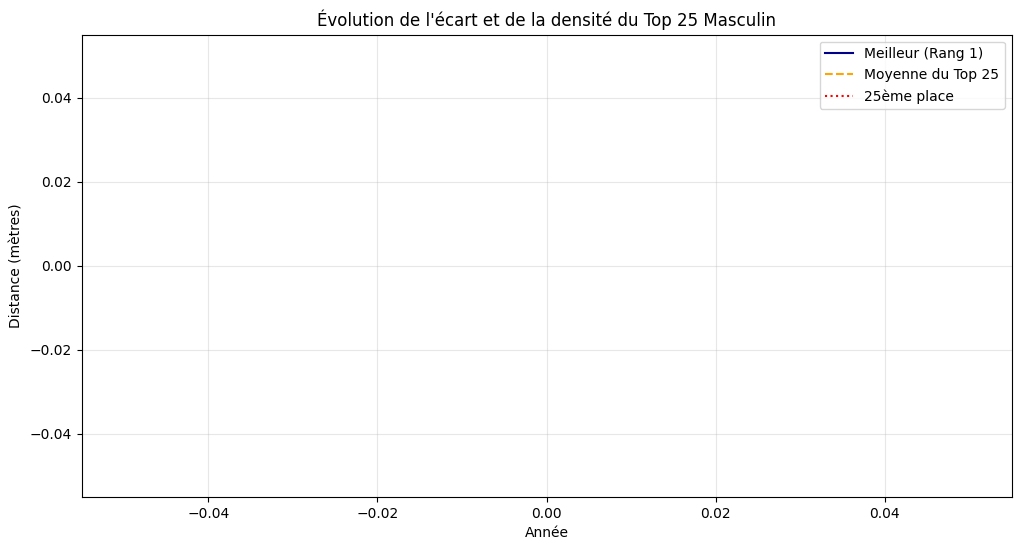


=== FAITS MARQUANTS ===


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_excel("triple_saut_1891_2019.xlsx")

df['Performance (m)'] = pd.to_numeric(df['Performance (m)'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df = df.dropna(subset=['Performance (m)'])

df['Rang'] = pd.to_numeric(df['Rang'], errors='coerce')

print(f"Nombre de lignes valides pour l'analyse : {len(df)}")
print("-" * 50)

plt.figure(figsize=(12, 6))
df_rec = df[df['Rang'] == 1]

sns.lineplot(data=df_rec, x='Année', y='Performance (m)', hue='Genre', marker='o', linewidth=2)
plt.title("Évolution de la meilleure performance annuelle en Triple Saut (1891-2019)")
plt.xlabel("Année")
plt.ylabel("Distance (mètres)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("evolution_records_annuels.png")
plt.show()

plt.figure(figsize=(10, 5))
top_pays = df['Pays'].value_counts().head(10)

sns.barplot(x=top_pays.values, y=top_pays.index, palette="viridis")
plt.title("Top 10 des pays les plus représentés dans les bilans mondiaux (1891-2019)")
plt.xlabel("Nombre d'entrées dans le Top 25")
plt.ylabel("Code Pays")
plt.savefig("domination_par_pays.png")
plt.show()

plt.figure(figsize=(12, 6))
df_hommes = df[df['Genre'] == 'Homme']
df_stats_h = df_hommes.groupby('Année')['Performance (m)'].agg(['max', 'mean', 'min']).reset_index()

plt.plot(df_stats_h['Année'], df_stats_h['max'], label="Meilleur (Rang 1)", color='darkblue')
plt.plot(df_stats_h['Année'], df_stats_h['mean'], label="Moyenne du Top 25", color='orange', linestyle='--')
plt.plot(df_stats_h['Année'], df_stats_h['min'], label="25ème place", color='red', linestyle=':')
plt.fill_between(df_stats_h['Année'], df_stats_h['min'], df_stats_h['max'], color='gray', alpha=0.15)

plt.title("Évolution de l'écart et de la densité du Top 25 Masculin")
plt.xlabel("Année")
plt.ylabel("Distance (mètres)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("densite_top25_masculin.png")
plt.show()

print("\n=== FAITS MARQUANTS ===")
for genre in ['Homme', 'Femme']:
    df_g = df[df['Genre'] == genre]
    if not df_g.empty:
        idx_max = df_g['Performance (m)'].idxmax()
        row_max = df_g.loc[idx_max]
        print(f"\nMeilleure performance historique enregistrée ({genre}) dans la base :")
        print(f"-> {row_max['Performance (m)']}m par {row_max['Athlète']} ({row_max['Pays']}) en {row_max['Année']}")